# Exploratory Data Analysis - Figshare Dataset

**Objective:** Analyze the Figshare public dataset to understand FoG patterns and data characteristics.

**Dataset:** 35 Parkinson's patients, IMU sensors (accelerometer + gyroscope), 64 Hz sampling rate

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loaders import FigshareDatasetLoader

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
# Load data (walking trials only)
loader = FigshareDatasetLoader('../../Datasets/Figshare a public dataset')
df = loader.load_all_data(verbose=True, trial_type='walking')

# Add subject and session string identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['session'] = df['session_id'].apply(lambda x: f'SE{x}')

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {df['subject'].nunique()}")
print(f"Trial type: {df['trial_type'].unique()}")
print(f"Total duration: {df['time_s'].max():.1f} seconds ({df['time_s'].max()/60:.1f} minutes)")

📁 Encontrados 71 archivos TXT
🔍 Filtrando por tipo: walking
📊 Cargando datos del dataset Figshare...



Cargando archivos: 100%|██████████| 71/71 [00:09<00:00,  7.50it/s]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: FigshareDatasetLoader

📊 Información General:
   Dimensiones: (1090560, 14)
   Filas: 1,090,560
   Columnas: 14
   Memoria: 271.90 MB

👥 Sujetos: 35
📁 Archivos: 71

🚨 Episodios de FoG:
   Muestras con FoG: 206,334 (18.92%)
   Muestras sin FoG: 884,226 (81.08%)


Dataset shape: (1090560, 16)
Subjects: 35
Trial type: <StringArray>
['walking']
Length: 1, dtype: str
Total duration: 120.0 seconds (2.0 minutes)


## 2. Data Structure

In [3]:
# Display first rows
df.head()

,frame,time_s,acc_ml_g,acc_ap_g,acc_si_g,gyr_ml_deg_s,gyr_ap_deg_s,gyr_si_deg_s,freezing_flag,subject_id,session_id,trial_type,filename,freezing_label,subject,session
0,1,0.007812,0.191745,-0.511756,1.014700,-10.448125,58.094807,29.161523,0,1,1,walking,SUB01_1.txt,No Freeze,S01,SE1
1,2,0.015625,0.226322,-0.258745,1.084140,-1.247650,56.511776,35.680386,0,1,1,walking,SUB01_1.txt,No Freeze,S01,SE1
2,3,0.023438,0.405319,-0.561918,0.915292,-3.488858,49.336805,38.986192,0,1,1,walking,SUB01_1.txt,No Freeze,S01,SE1
3,4,0.031250,0.620089,-0.285977,0.975270,7.025583,39.408962,71.966275,0,1,1,walking,SUB01_1.txt,No Freeze,S01,SE1
4,5,0.039062,0.488221,-1.063820,0.640557,-1.527005,33.880341,79.829072,0,1,1,walking,SUB01_1.txt,No Freeze,S01,SE1


In [4]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090560 entries, 0 to 1090559
Data columns (total 16 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   frame           1090560 non-null  int64  
 1   time_s          1090560 non-null  float64
 2   acc_ml_g        1090560 non-null  float64
 3   acc_ap_g        1090560 non-null  float64
 4   acc_si_g        1090560 non-null  float64
 5   gyr_ml_deg_s    1090560 non-null  float64
 6   gyr_ap_deg_s    1090560 non-null  float64
 7   gyr_si_deg_s    1090560 non-null  float64
 8   freezing_flag   1090560 non-null  int64  
 9   subject_id      1090560 non-null  int64  
 10  session_id      1090560 non-null  int64  
 11  trial_type      1090560 non-null  str    
 12  filename        1090560 non-null  str    
 13  freezing_label  1090560 non-null  str    
 14  subject         1090560 non-null  str    
 15  session         1090560 non-null  str    
dtypes: float64(7), int64(4), str(5)
memory usage: 1

In [5]:
# Statistical summary
df.describe()

,frame,time_s,acc_ml_g,acc_ap_g,acc_si_g,gyr_ml_deg_s,gyr_ap_deg_s,gyr_si_deg_s,freezing_flag,subject_id,session_id
count,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06,1.090560e+06
mean,7.680500e+03,6.000391e+01,3.059837e-02,-2.496601e-01,9.773827e-01,-3.760616e+00,7.367288e-01,-1.570570e+00,1.892000e-01,1.878873e+01,1.690141e+00
std,4.434052e+03,3.464103e+01,5.645352e-01,4.178074e-01,3.297816e-01,3.501213e+01,4.133092e+01,1.289649e+02,3.916676e-01,1.002942e+01,7.616063e-01
min,1.000000e+00,7.812500e-03,-8.561559e+00,-8.761489e+00,-7.205222e+00,-8.328335e+02,-3.372607e+02,-1.039652e+03,0.000000e+00,1.000000e+00,1.000000e+00
25%,3.840750e+03,3.000586e+01,-1.045563e-01,-3.298631e-01,9.208678e-01,-1.093880e+01,-1.319441e+01,-2.517524e+01,0.000000e+00,1.000000e+01,1.000000e+00
50%,7.680500e+03,6.000391e+01,2.864193e-02,-2.190791e-01,9.762873e-01,7.689217e-02,9.196744e-01,-1.112511e+00,0.000000e+00,2.000000e+01,2.000000e+00
75%,1.152025e+04,9.000195e+01,1.659377e-01,-1.123686e-01,1.038256e+00,9.165269e+00,1.426378e+01,2.303421e+01,0.000000e+00,2.700000e+01,2.000000e+00
max,1.536000e+04,1.200000e+02,8.562497e+00,8.078460e+00,8.092385e+00,8.057459e+02,6.572037e+02,1.149803e+03,1.000000e+00,3.500000e+01,3.000000e+00


## 3. FoG Distribution Analysis

Labels: 0 = No Freeze, 1 = Freeze

In [6]:
# Overall FoG distribution
fog_counts = df['freezing_flag'].value_counts().sort_index()
fog_pct = (fog_counts / len(df) * 100).round(2)

print("FoG Distribution:")
print(f"  No Freeze (0): {fog_counts[0]:,} samples ({fog_pct[0]}%)")
print(f"  Freeze (1):    {fog_counts[1]:,} samples ({fog_pct[1]}%)")
print(f"\nClass imbalance ratio: {fog_counts[0]/fog_counts[1]:.1f}:1")

FoG Distribution:
  No Freeze (0): 884,226 samples (81.08%)
  Freeze (1):    206,334 samples (18.92%)

Class imbalance ratio: 4.3:1


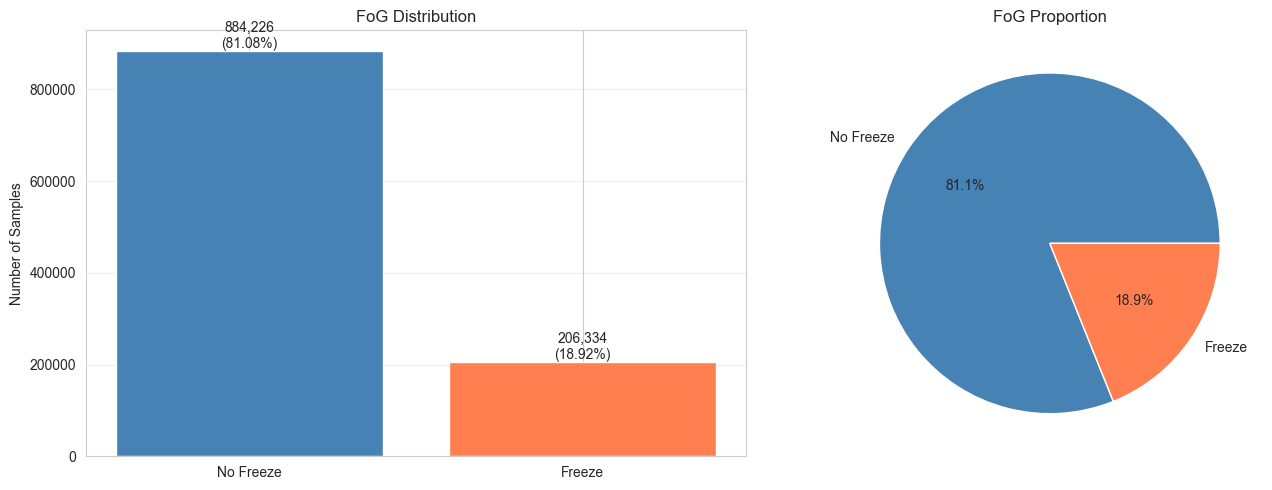

In [7]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1.bar(['No Freeze', 'Freeze'], fog_counts.values, color=['steelblue', 'coral'])
ax1.set_ylabel('Number of Samples')
ax1.set_title('FoG Distribution')
ax1.grid(axis='y', alpha=0.3)
for i, (count, pct) in enumerate(zip(fog_counts.values, fog_pct.values)):
    ax1.text(i, count, f'{count:,}\n({pct}%)', ha='center', va='bottom')

# Pie chart
ax2.pie(fog_counts.values, labels=['No Freeze', 'Freeze'], autopct='%1.1f%%',
        colors=['steelblue', 'coral'])
ax2.set_title('FoG Proportion')

plt.tight_layout()
plt.show()

## 4. Subject-Level Analysis

In [8]:
# Samples per subject
subject_summary = df.groupby('subject').agg({
    'time_s': 'count',
    'freezing_flag': lambda x: (x == 1).sum()
}).rename(columns={'time_s': 'total_samples', 'freezing_flag': 'freeze_samples'})

subject_summary['freeze_percentage'] = (subject_summary['freeze_samples'] / 
                                         subject_summary['total_samples'] * 100).round(2)

print("Subject Statistics:")
print(subject_summary)

Subject Statistics:
         total_samples  freeze_samples  freeze_percentage
subject                                                  
S01              30720           29576              96.28
S02              15360           13771              89.65
S03              46080             346               0.75
S04              15360            2179              14.19
S05              30720            2993               9.74
S06              30720             290               0.94
S07              46080           45490              98.72
S08              15360           10474              68.19
S09              30720            2669               8.69
S10              30720               0               0.00
S11              30720            3913              12.74
S12              15360               0               0.00
S13              15360               0               0.00
S14              46080           10755              23.34
S15              15360             509              

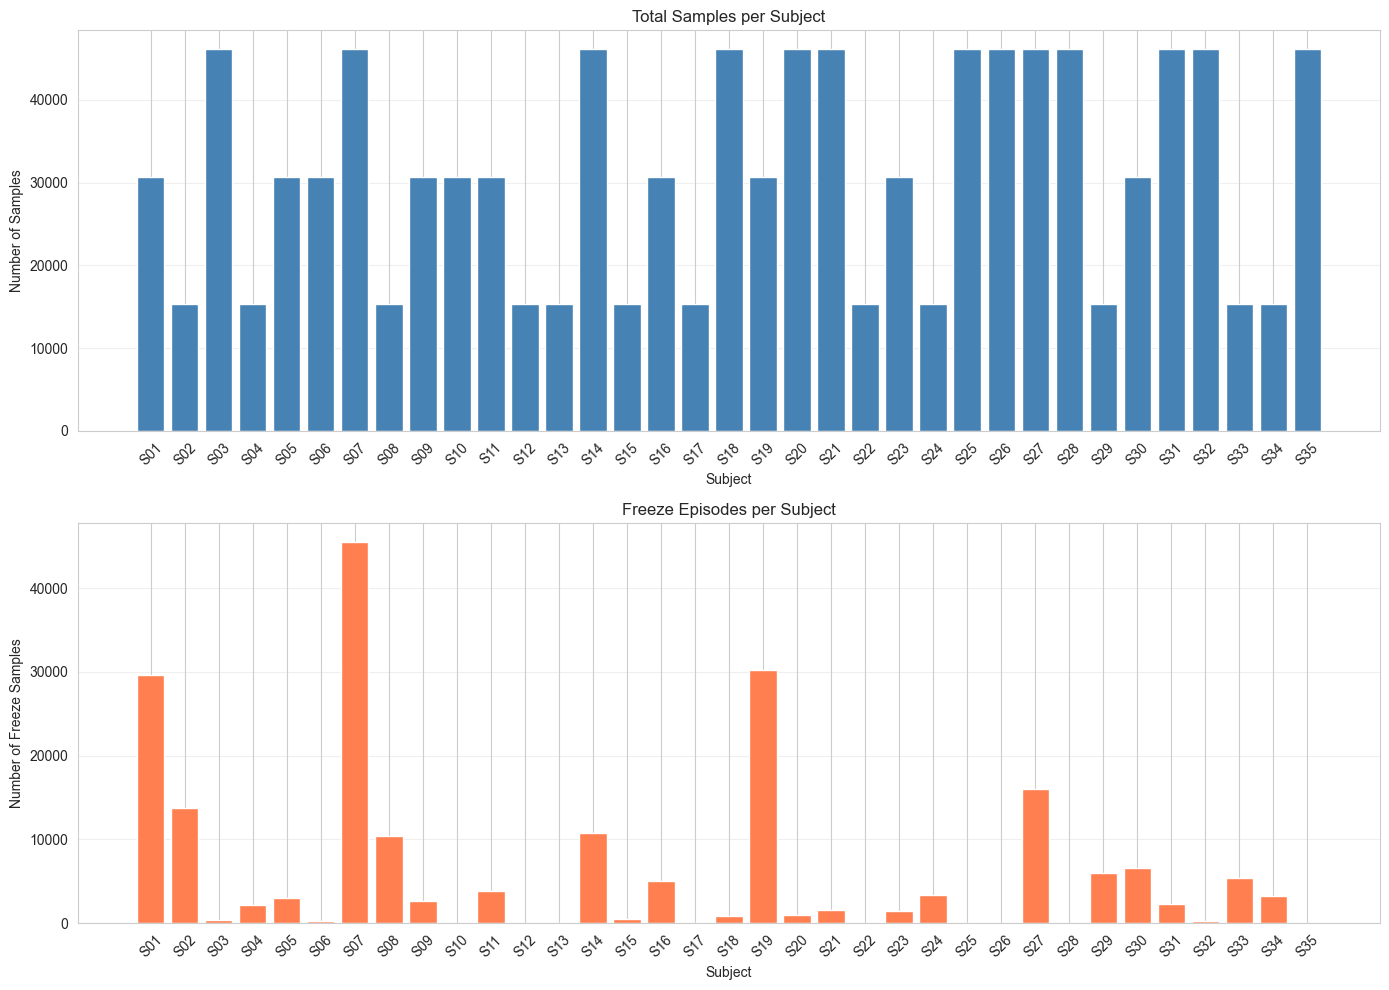

In [9]:
# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Total samples per subject
ax1.bar(subject_summary.index, subject_summary['total_samples'], color='steelblue')
ax1.set_xlabel('Subject')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Subject')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# FoG samples per subject
ax2.bar(subject_summary.index, subject_summary['freeze_samples'], color='coral')
ax2.set_xlabel('Subject')
ax2.set_ylabel('Number of Freeze Samples')
ax2.set_title('Freeze Episodes per Subject')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Sensor Data Analysis

In [10]:
# Sensor columns: accelerometer + gyroscope
sensor_cols = ['acc_ml_g', 'acc_ap_g', 'acc_si_g',
               'gyr_ml_deg_s', 'gyr_ap_deg_s', 'gyr_si_deg_s']

print("Sensor measurements:")
for col in sensor_cols:
    print(f"  {col}")

Sensor measurements:
  acc_ml_g
  acc_ap_g
  acc_si_g
  gyr_ml_deg_s
  gyr_ap_deg_s
  gyr_si_deg_s


In [11]:
# Compare sensor statistics for FoG vs No FoG
freeze_data = df[df['freezing_flag'] == 1][sensor_cols]
no_freeze_data = df[df['freezing_flag'] == 0][sensor_cols]

print("Sensor Statistics Comparison (Mean):")
print("\nNo Freeze:")
print(no_freeze_data.mean())
print("\nFreeze:")
print(freeze_data.mean())

Sensor Statistics Comparison (Mean):

No Freeze:
acc_ml_g        0.023221
acc_ap_g       -0.269829
acc_si_g        0.979795
gyr_ml_deg_s   -4.270519
gyr_ap_deg_s    0.637759
gyr_si_deg_s   -1.821036
dtype: float64

Freeze:
acc_ml_g        0.062212
acc_ap_g       -0.163226
acc_si_g        0.967043
gyr_ml_deg_s   -1.575469
gyr_ap_deg_s    1.160854
gyr_si_deg_s   -0.497219
dtype: float64


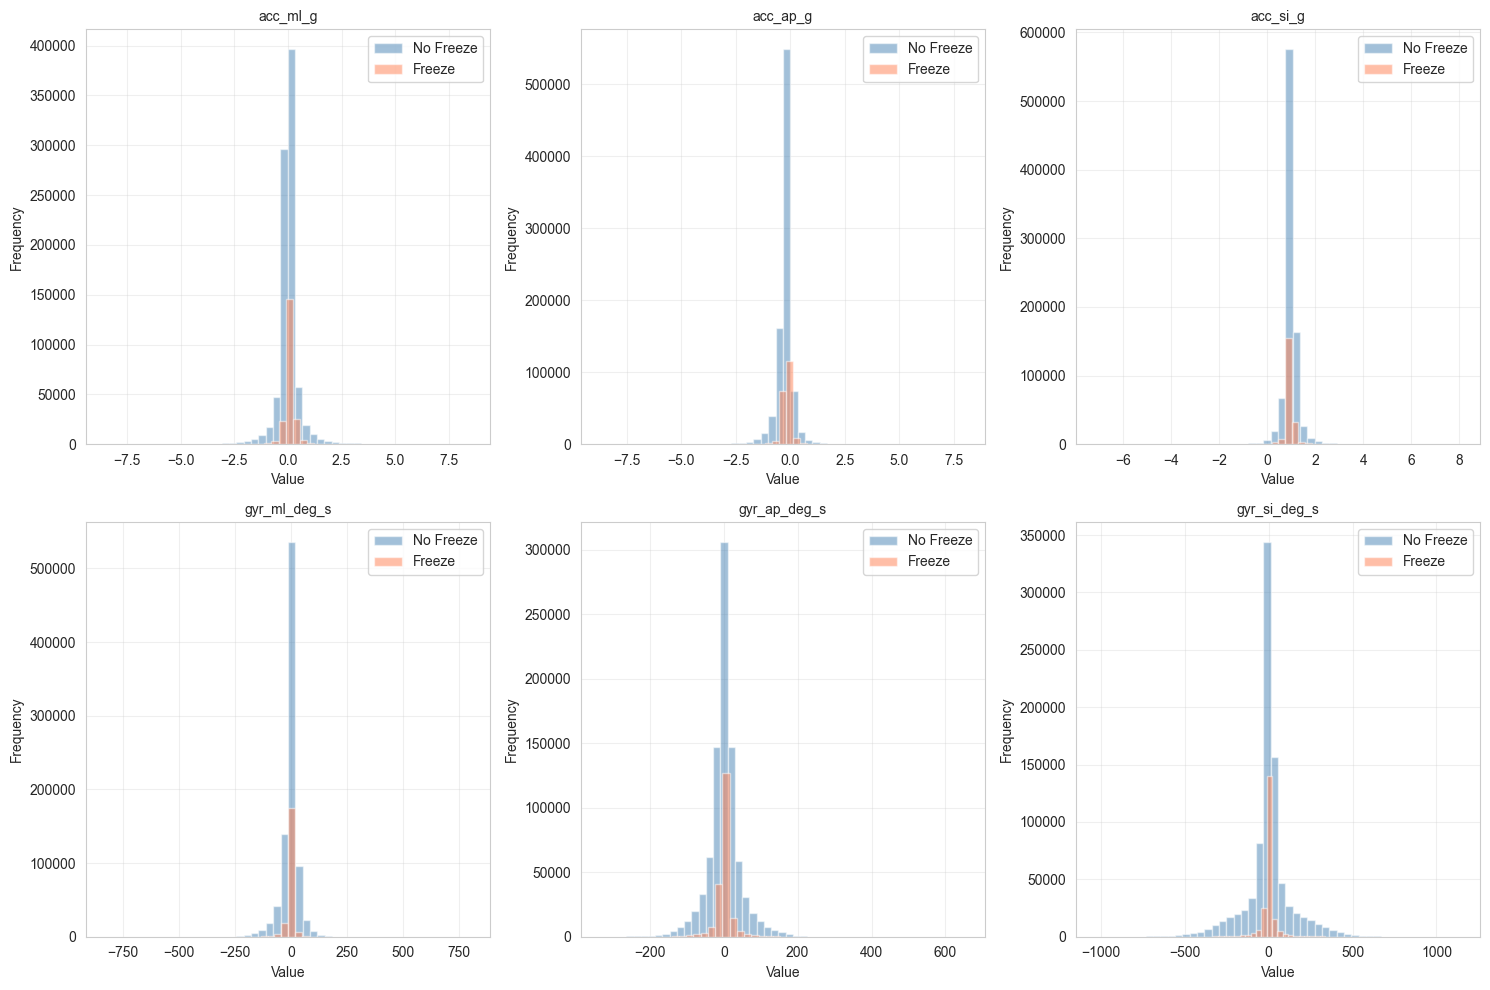

In [12]:
# Visualize sensor distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(sensor_cols):
    axes[i].hist(no_freeze_data[col], bins=50, alpha=0.5, label='No Freeze', color='steelblue')
    axes[i].hist(freeze_data[col], bins=50, alpha=0.5, label='Freeze', color='coral')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

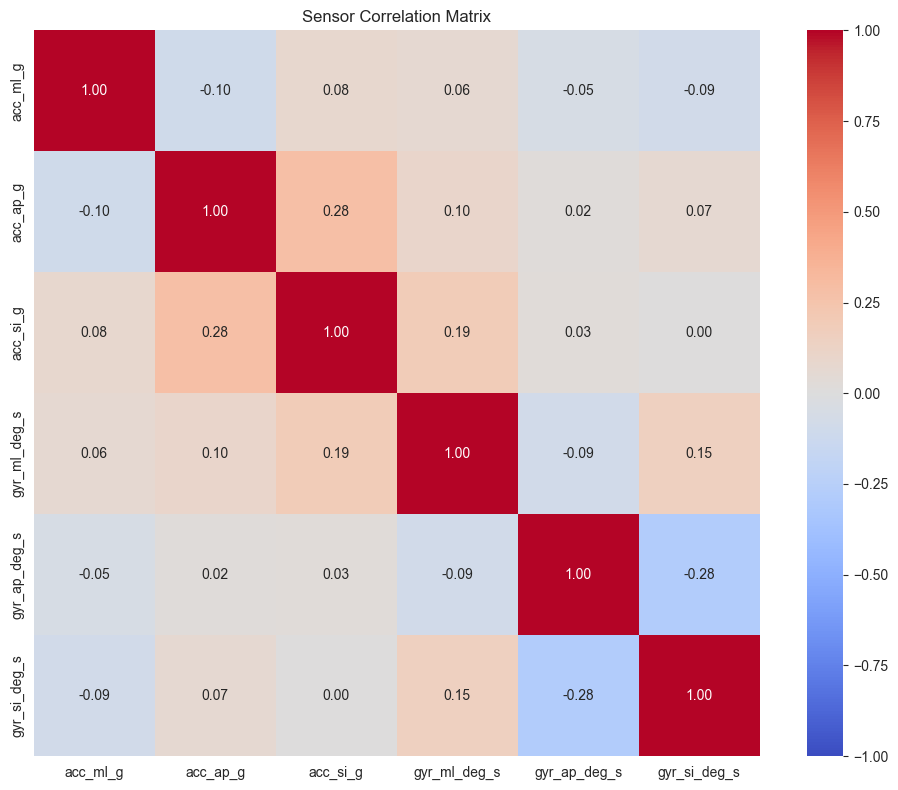

In [13]:
# Correlation matrix
corr_matrix = df[sensor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Sensor Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Temporal Patterns - Example Freeze Episode

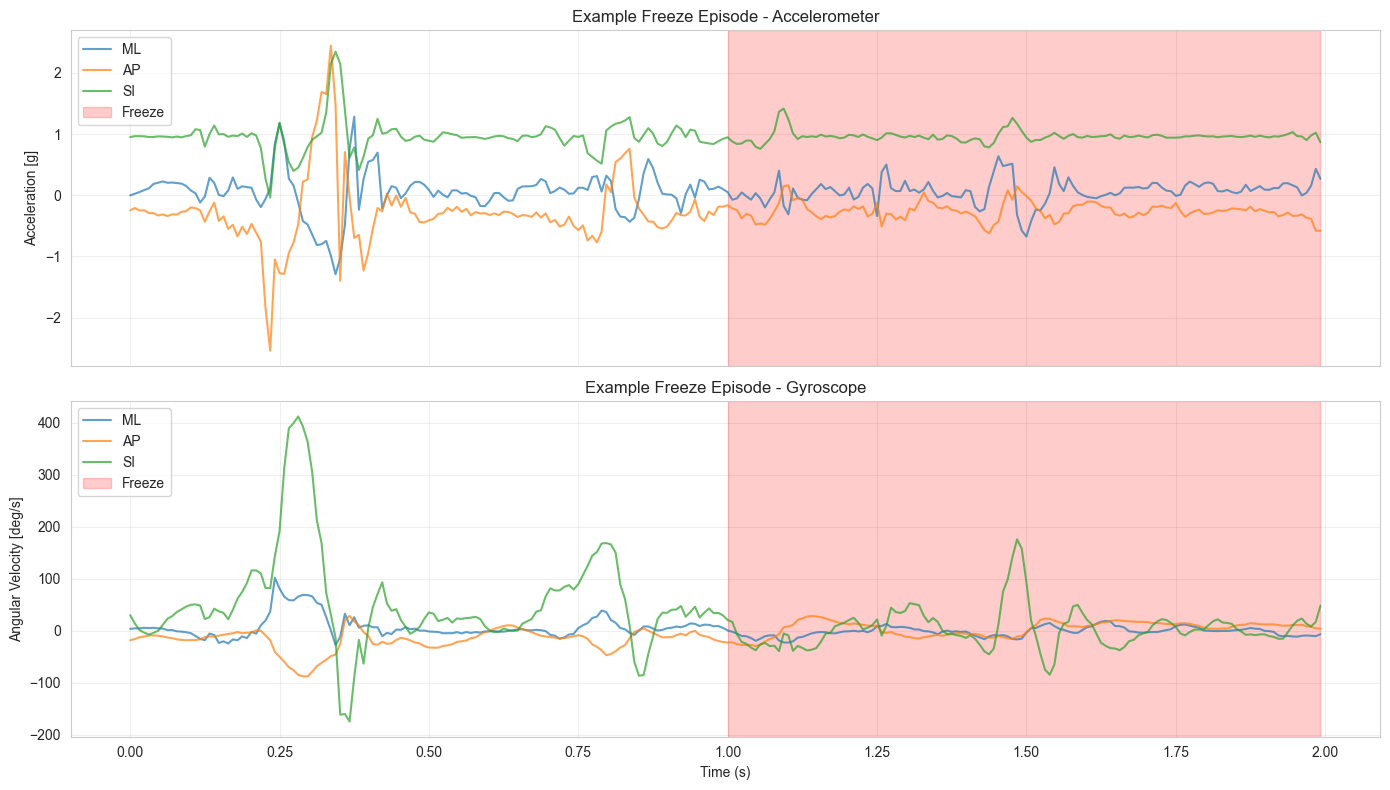

In [14]:
# Find a freeze episode and plot signals
subject = 'S01'
session = 'SE1'
mask = (df['subject'] == subject) & (df['session'] == session)
episode_data = df[mask].reset_index(drop=True)

# Find first freeze episode
freeze_indices = episode_data[episode_data['freezing_flag'] == 1].index
if len(freeze_indices) > 0:
    # Take 256 samples around freeze (4 seconds @ 64Hz)
    center = freeze_indices[0]
    start = max(0, center - 128)
    end = min(len(episode_data), center + 128)
    window = episode_data.iloc[start:end]
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    time = window['time_s'].values - window['time_s'].values[0]
    
    # Accelerometer
    axes[0].plot(time, window['acc_ml_g'], label='ML', alpha=0.7)
    axes[0].plot(time, window['acc_ap_g'], label='AP', alpha=0.7)
    axes[0].plot(time, window['acc_si_g'], label='SI', alpha=0.7)
    axes[0].axvspan(time[window['freezing_flag']==1].min(), 
                     time[window['freezing_flag']==1].max(), 
                     alpha=0.2, color='red', label='Freeze')
    axes[0].set_ylabel('Acceleration [g]')
    axes[0].set_title('Example Freeze Episode - Accelerometer')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Gyroscope
    axes[1].plot(time, window['gyr_ml_deg_s'], label='ML', alpha=0.7)
    axes[1].plot(time, window['gyr_ap_deg_s'], label='AP', alpha=0.7)
    axes[1].plot(time, window['gyr_si_deg_s'], label='SI', alpha=0.7)
    axes[1].axvspan(time[window['freezing_flag']==1].min(), 
                     time[window['freezing_flag']==1].max(), 
                     alpha=0.2, color='red', label='Freeze')
    axes[1].set_ylabel('Angular Velocity [deg/s]')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title('Example Freeze Episode - Gyroscope')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No freeze episodes found in {subject} {session}")

## Summary

**Key Findings:**
1. Class imbalance: Freeze episodes represent minority of samples
2. Subject variability: Different patients show different freeze patterns
3. Sensor characteristics: IMU data with 3-axis accelerometer and gyroscope
4. Freeze characteristics visible in both accelerometer and gyroscope signals

**Implications for ML:**
- Need to address class imbalance (ADASYN, class weights)
- Subject-independent validation critical (LOSO)
- Feature engineering from both accelerometer and gyroscope important
- Temporal patterns suggest window-based approach